# E-commerce A/B Testing with Revenue Forecasting

## Notebook 2: Exploratory Data Analysis

This notebook explores the cleaned A/B testing dataset and the cleaned store sales forecasting tables. The goal is to understand experiment behavior, conversion patterns, sales trends, seasonality, and data issues before feature engineering and modeling.

## Goals

1. Explore A/B test structure and funnel behavior
2. Compare control and test performance
3. Explore store sales trends and seasonality
4. Inspect oil and transactions behavior
5. Identify patterns that matter for forecasting and scenario analysis

In [1]:
# Import libraries

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set display options and project paths

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)

PROJECT_ROOT = Path.cwd().parent
PREPROCESSED_DIR = PROJECT_ROOT / "data" / "02-preprocessed"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

REPORTS_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Preprocessed dir exists:", PREPROCESSED_DIR.exists())
print("Figures dir exists:", REPORTS_FIGURES_DIR.exists())

Project root: c:\Users\tevin\OneDrive\Desktop\General-Machine-Learning\revenue_forecasting
Preprocessed dir exists: True
Figures dir exists: True


In [3]:
# Load preprocessed datasets

ab_df = pd.read_csv(PREPROCESSED_DIR / "ab_test_clean.csv", parse_dates=["date"])

train_df = pd.read_csv(PREPROCESSED_DIR / "store_sales_train_clean.csv", parse_dates=["date"])
test_df_store = pd.read_csv(PREPROCESSED_DIR / "store_sales_test_clean.csv", parse_dates=["date"])
transactions_df = pd.read_csv(PREPROCESSED_DIR / "store_sales_transactions_clean.csv", parse_dates=["date"])
oil_df = pd.read_csv(PREPROCESSED_DIR / "store_sales_oil_clean.csv", parse_dates=["date"])
holidays_df = pd.read_csv(PREPROCESSED_DIR / "store_sales_holidays_clean.csv", parse_dates=["date"])
stores_df = pd.read_csv(PREPROCESSED_DIR / "store_sales_stores_clean.csv")

print("ab_df:", ab_df.shape)
print("train_df:", train_df.shape)
print("transactions_df:", transactions_df.shape)
print("oil_df:", oil_df.shape)
print("holidays_df:", holidays_df.shape)
print("stores_df:", stores_df.shape)

ab_df: (60, 11)
train_df: (3000888, 6)
transactions_df: (83488, 3)
oil_df: (1218, 2)
holidays_df: (350, 6)
stores_df: (54, 5)


## A/B Test Overview

This section explores the experiment dataset, variant sizes, and basic funnel totals before formal testing.

In [4]:
# Preview A/B test data

ab_df.head()

,campaign_name,date,spend_usd,impressions,reach,website_clicks,searches,view_content,add_to_cart,purchase,variant
0,Control Campaign,2019-01-08,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-02-08,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-03-08,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-04-08,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-05-08,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


In [5]:
# Summarize A/B test by variant

ab_variant_summary = ab_df.groupby("variant").agg(
    rows=("variant", "count"),
    total_spend=("spend_usd", "sum"),
    total_impressions=("impressions", "sum"),
    total_reach=("reach", "sum"),
    total_clicks=("website_clicks", "sum"),
    total_searches=("searches", "sum"),
    total_view_content=("view_content", "sum"),
    total_add_to_cart=("add_to_cart", "sum"),
    total_purchases=("purchase", "sum")
).reset_index()

ab_variant_summary

,variant,rows,total_spend,total_impressions,total_reach,total_clicks,total_searches,total_view_content,total_add_to_cart,total_purchases
0,control,30,68653,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0
1,test,30,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0


## A/B Funnel Metrics

This section derives simple funnel conversion metrics to compare control and test performance.

In [6]:
# Create funnel metrics by variant

ab_funnel_metrics = ab_variant_summary.copy()

ab_funnel_metrics["ctr"] = ab_funnel_metrics["total_clicks"] / ab_funnel_metrics["total_impressions"]
ab_funnel_metrics["search_rate"] = ab_funnel_metrics["total_searches"] / ab_funnel_metrics["total_clicks"]
ab_funnel_metrics["view_content_rate"] = ab_funnel_metrics["total_view_content"] / ab_funnel_metrics["total_clicks"]
ab_funnel_metrics["add_to_cart_rate"] = ab_funnel_metrics["total_add_to_cart"] / ab_funnel_metrics["total_view_content"]
ab_funnel_metrics["purchase_rate_from_click"] = ab_funnel_metrics["total_purchases"] / ab_funnel_metrics["total_clicks"]
ab_funnel_metrics["purchase_rate_from_impression"] = ab_funnel_metrics["total_purchases"] / ab_funnel_metrics["total_impressions"]
ab_funnel_metrics["cost_per_purchase"] = ab_funnel_metrics["total_spend"] / ab_funnel_metrics["total_purchases"]

ab_funnel_metrics

,variant,rows,total_spend,total_impressions,total_reach,total_clicks,total_searches,total_view_content,total_add_to_cart,total_purchases,ctr,search_rate,view_content_rate,add_to_cart_rate,purchase_rate_from_click,purchase_rate_from_impression,cost_per_purchase
0,control,30,68653,3177233.0,2576503.0,154303.0,64418.0,56370.0,37700.0,15161.0,0.048565,0.417477,0.365320,0.668795,0.098255,0.004772,4.528263
1,test,30,76892,2237544.0,1604747.0,180970.0,72569.0,55740.0,26446.0,15637.0,0.080879,0.401000,0.308007,0.474453,0.086407,0.006988,4.917312


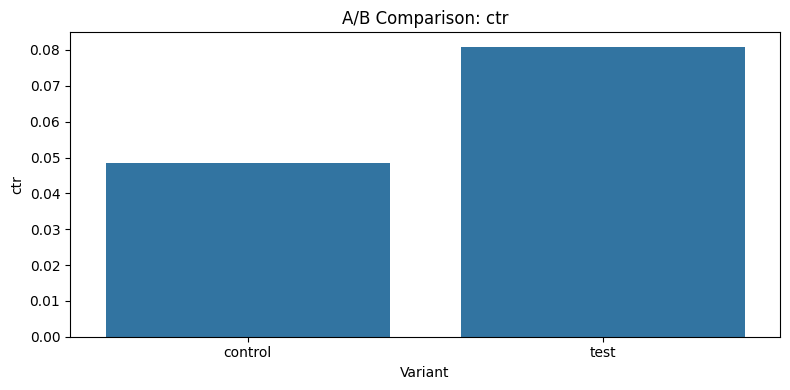

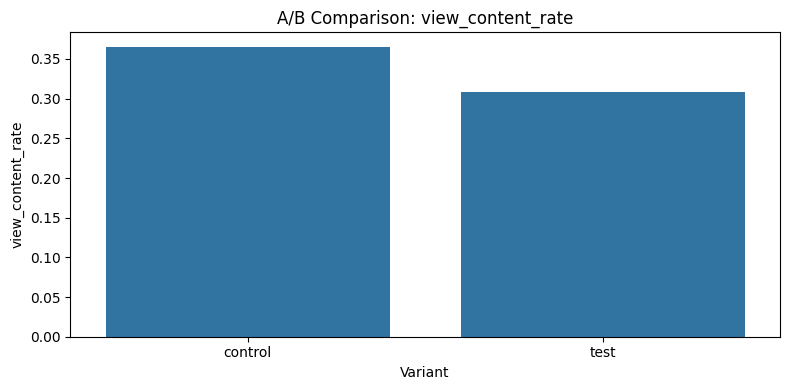

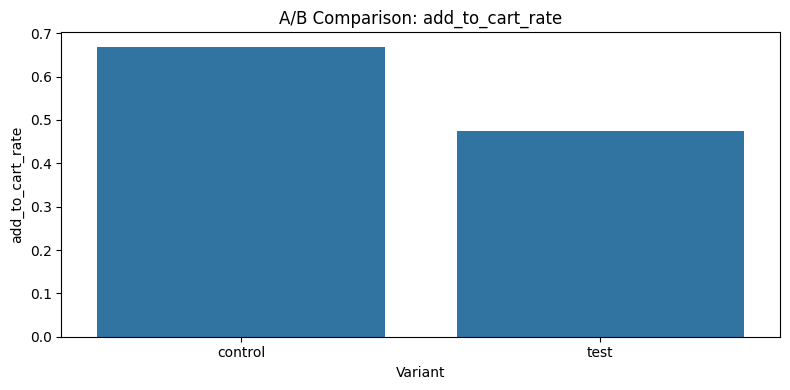

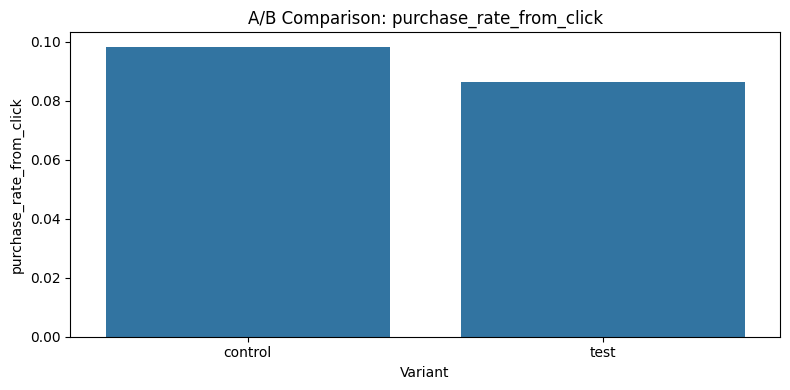

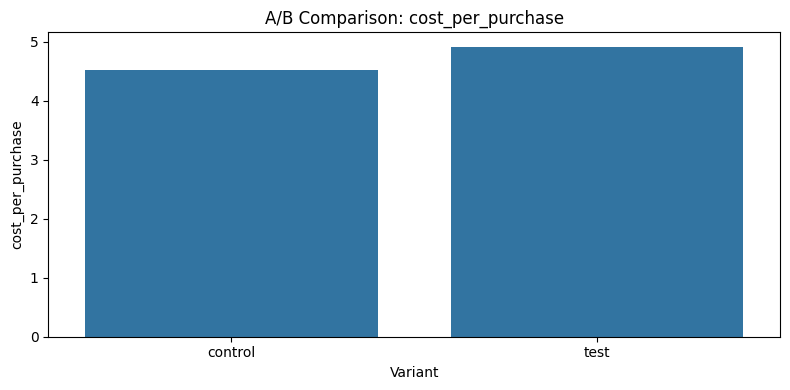

In [7]:
# Plot key A/B funnel comparisons

plot_cols = [
    "ctr",
    "view_content_rate",
    "add_to_cart_rate",
    "purchase_rate_from_click",
    "cost_per_purchase"
]

for col in plot_cols:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=ab_funnel_metrics, x="variant", y=col)
    plt.title(f"A/B Comparison: {col}")
    plt.xlabel("Variant")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [8]:
# Aggregate A/B data by date and variant

ab_daily = (
    ab_df.groupby(["date", "variant"], as_index=False)
    .agg(
        spend_usd=("spend_usd", "sum"),
        impressions=("impressions", "sum"),
        website_clicks=("website_clicks", "sum"),
        view_content=("view_content", "sum"),
        add_to_cart=("add_to_cart", "sum"),
        purchase=("purchase", "sum")
    )
    .sort_values(["variant", "date"])
)

ab_daily["purchase_rate_from_click"] = ab_daily["purchase"] / ab_daily["website_clicks"]
ab_daily["ctr"] = ab_daily["website_clicks"] / ab_daily["impressions"]

ab_daily.head()

,date,variant,spend_usd,impressions,website_clicks,view_content,add_to_cart,purchase,purchase_rate_from_click,ctr
0,2019-01-08,control,2280,82702.0,7016.0,2159.0,1819.0,618.0,0.088084,0.084835
2,2019-02-08,control,1757,121040.0,8110.0,1841.0,1219.0,511.0,0.063009,0.067003
4,2019-03-08,control,2343,131711.0,6508.0,1549.0,1134.0,372.0,0.057160,0.049411
6,2019-04-08,control,1940,72878.0,3065.0,982.0,1183.0,340.0,0.110930,0.042057
8,2019-05-08,control,1835,0.0,0.0,0.0,0.0,0.0,NaN,NaN


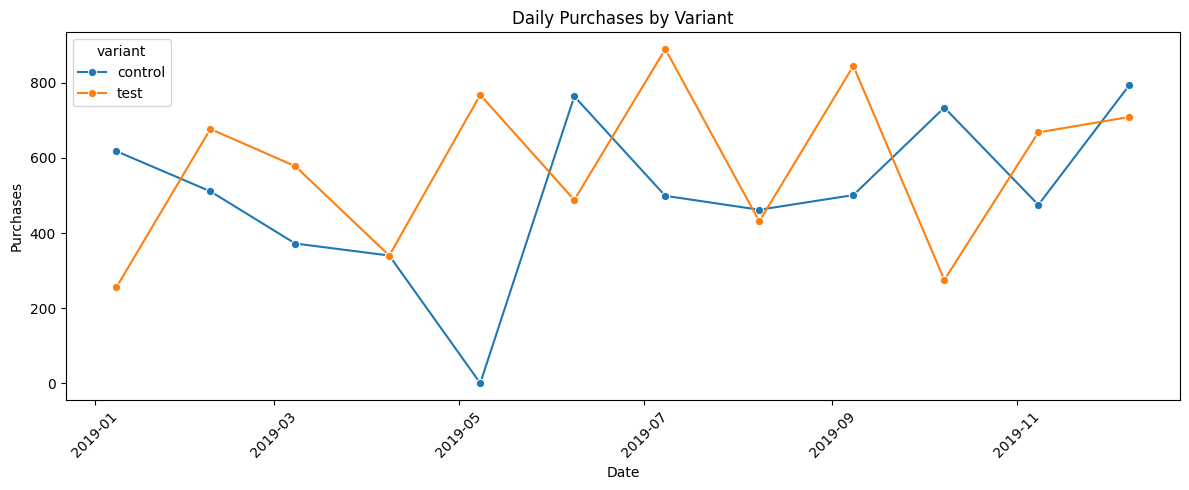

In [9]:
# Plot daily purchases by variant

plt.figure(figsize=(12, 5))
sns.lineplot(data=ab_daily, x="date", y="purchase", hue="variant", marker="o")
plt.title("Daily Purchases by Variant")
plt.xlabel("Date")
plt.ylabel("Purchases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

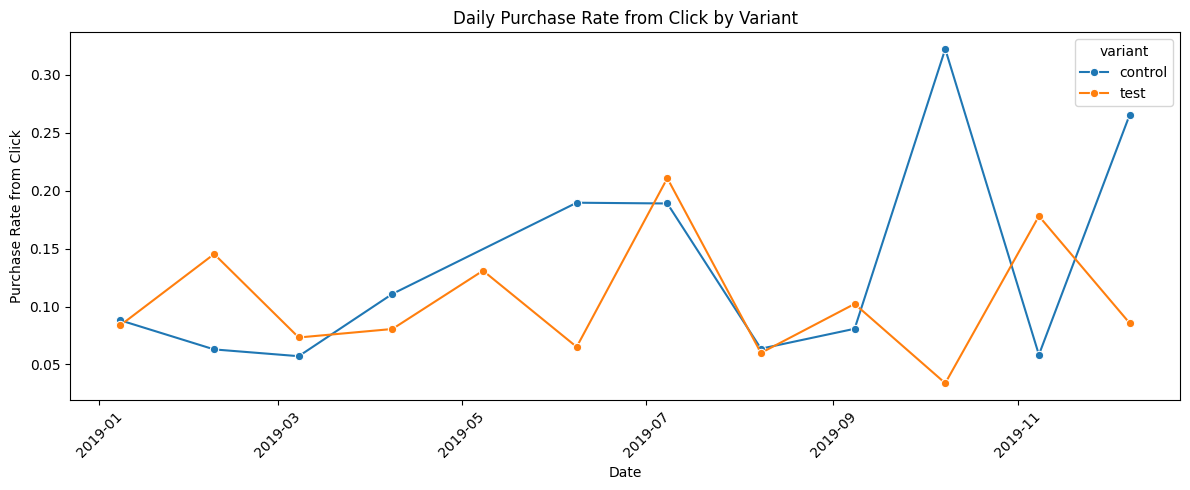

In [11]:
# Plot daily purchase rate from click by variant

plt.figure(figsize=(12, 5))
sns.lineplot(data=ab_daily, x="date", y="purchase_rate_from_click", hue="variant", marker="o")
plt.title("Daily Purchase Rate from Click by Variant")
plt.xlabel("Date")
plt.ylabel("Purchase Rate from Click")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Store Sales Overview

This section explores the main sales target and its high-level structure before deeper trend analysis.

In [12]:
# Preview train sales data

train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [13]:
# Aggregate total daily sales

daily_sales = (
    train_df.groupby("date", as_index=False)
    .agg(
        total_sales=("sales", "sum"),
        total_onpromotion=("onpromotion", "sum")
    )
    .sort_values("date")
)

daily_sales.head()

,date,total_sales,total_onpromotion
0,2013-01-01,2511.618999,0
1,2013-01-02,496092.417944,0
2,2013-01-03,361461.231124,0
3,2013-01-04,354459.677093,0
4,2013-01-05,477350.121229,0


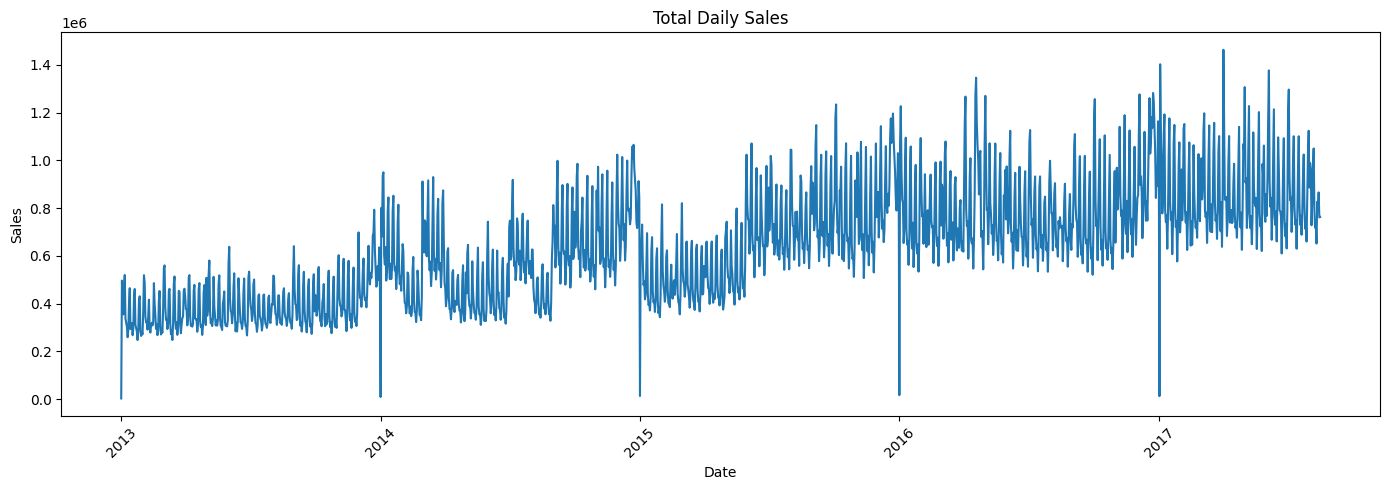

In [14]:
# Plot total daily sales

plt.figure(figsize=(14, 5))
plt.plot(daily_sales["date"], daily_sales["total_sales"])
plt.title("Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Sales Seasonality

This section explores recurring sales patterns that are likely to matter for forecasting.

In [15]:
# Create calendar features for daily sales EDA

daily_sales["year"] = daily_sales["date"].dt.year
daily_sales["month"] = daily_sales["date"].dt.month
daily_sales["day_of_week"] = daily_sales["date"].dt.day_name()
daily_sales["day_of_week_num"] = daily_sales["date"].dt.dayofweek

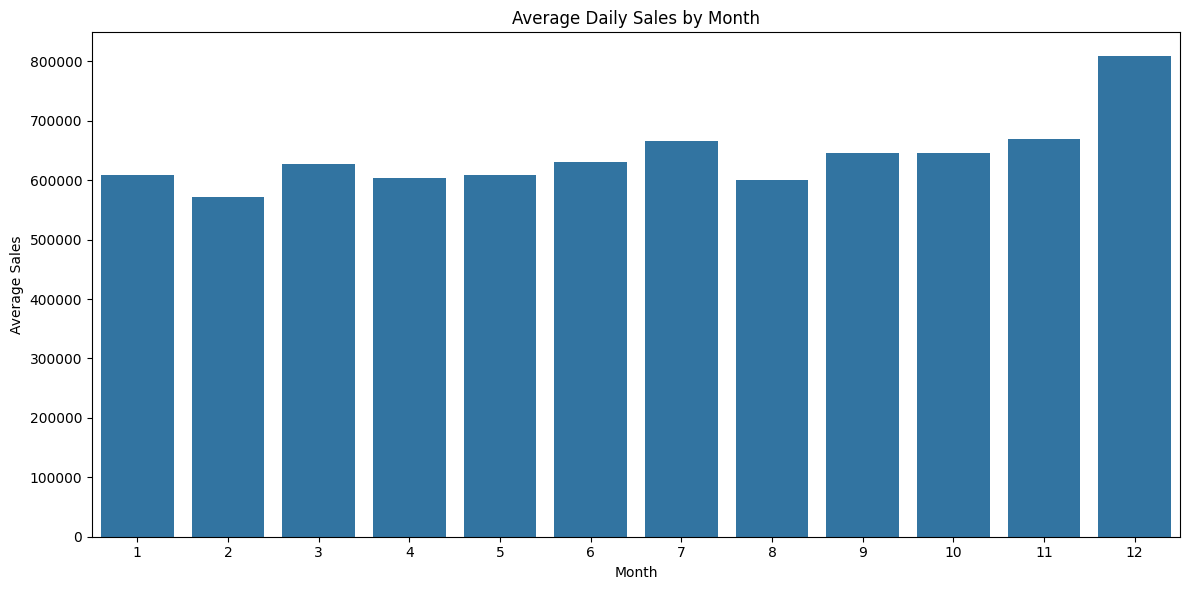

In [17]:
# Plot average sales by month

monthly_avg_sales = (
    daily_sales.groupby("month", as_index=False)
    .agg(avg_sales=("total_sales", "mean"))
)

plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_avg_sales, x="month", y="avg_sales")
plt.title("Average Daily Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()

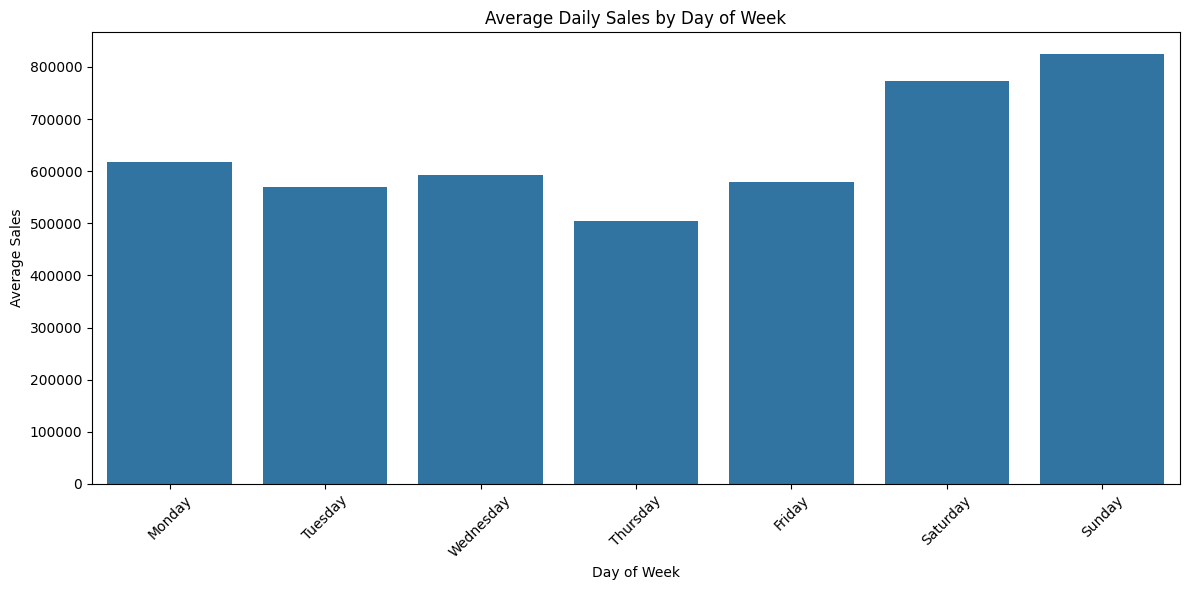

In [18]:
# Plot average sales by day of week

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_avg_sales = (
    daily_sales.groupby(["day_of_week", "day_of_week_num"], as_index=False)
    .agg(avg_sales=("total_sales", "mean"))
    .sort_values("day_of_week_num")
)

plt.figure(figsize=(12, 6))
sns.barplot(data=dow_avg_sales, x="day_of_week", y="avg_sales", order=dow_order)
plt.title("Average Daily Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Store and Product Family Analysis

This section identifies which stores and product families drive the most sales.

In [19]:
# Summarize total sales by store

store_sales_summary = (
    train_df.groupby("store_nbr", as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

store_sales_summary.head(10)

,store_nbr,total_sales
43,44,6.208755e+07
44,45,5.449801e+07
46,47,5.094831e+07
2,3,5.048191e+07
48,49,4.342010e+07
45,46,4.189606e+07
47,48,3.593313e+07
50,51,3.291149e+07
7,8,3.049429e+07
49,50,2.865302e+07


In [21]:
# Summarize total sales by product family

family_sales_summary = (
    train_df.groupby("family", as_index=False)
    .agg(total_sales=("sales", "sum"))
    .sort_values("total_sales", ascending=False)
)

family_sales_summary.head(15)

,family,total_sales
12,GROCERY I,3.434627e+08
3,BEVERAGES,2.169545e+08
30,PRODUCE,1.227047e+08
7,CLEANING,9.752129e+07
8,DAIRY,6.448771e+07
5,BREAD/BAKERY,4.213395e+07
28,POULTRY,3.187600e+07
24,MEATS,3.108647e+07
25,PERSONAL CARE,2.459205e+07
9,DELI,2.411032e+07


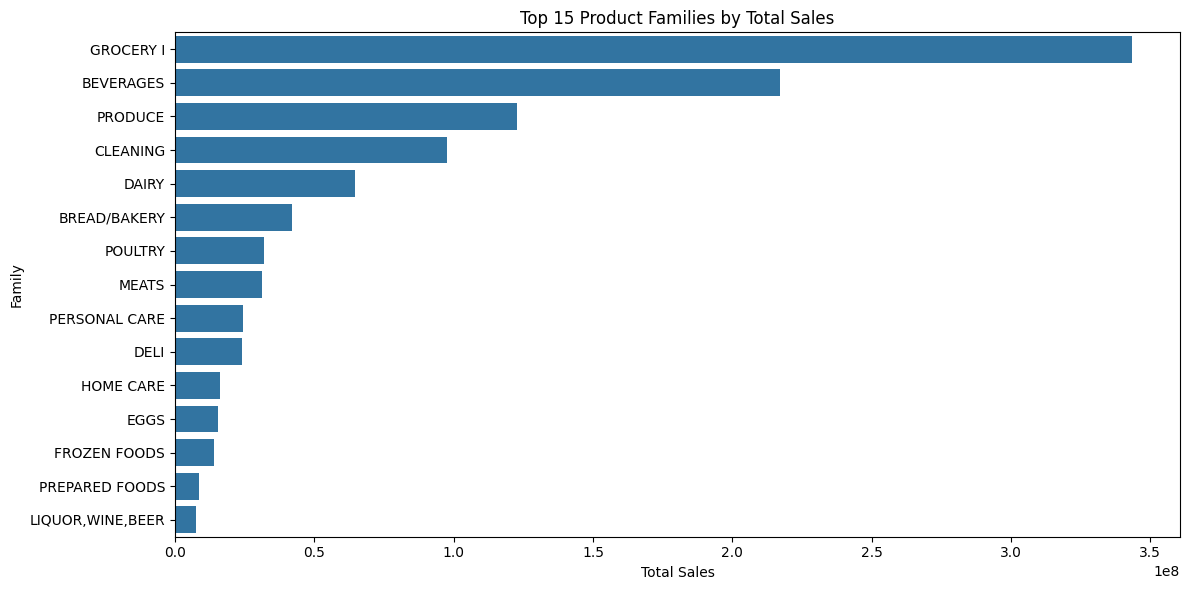

In [25]:
# Plot top product families by sales

top_families = family_sales_summary.head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_families, x="total_sales", y="family")
plt.title("Top 15 Product Families by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Family")
plt.tight_layout()
plt.show()

## Transactions Trend Analysis

This section reviews transaction trends over time and their relationship with sales.

In [26]:
# Aggregate daily transactions

daily_transactions = (
    transactions_df.groupby("date", as_index=False)
    .agg(total_transactions=("transactions", "sum"))
    .sort_values("date")
)

daily_transactions.head()

,date,total_transactions
0,2013-01-01,770
1,2013-01-02,93215
2,2013-01-03,78504
3,2013-01-04,78494
4,2013-01-05,93573


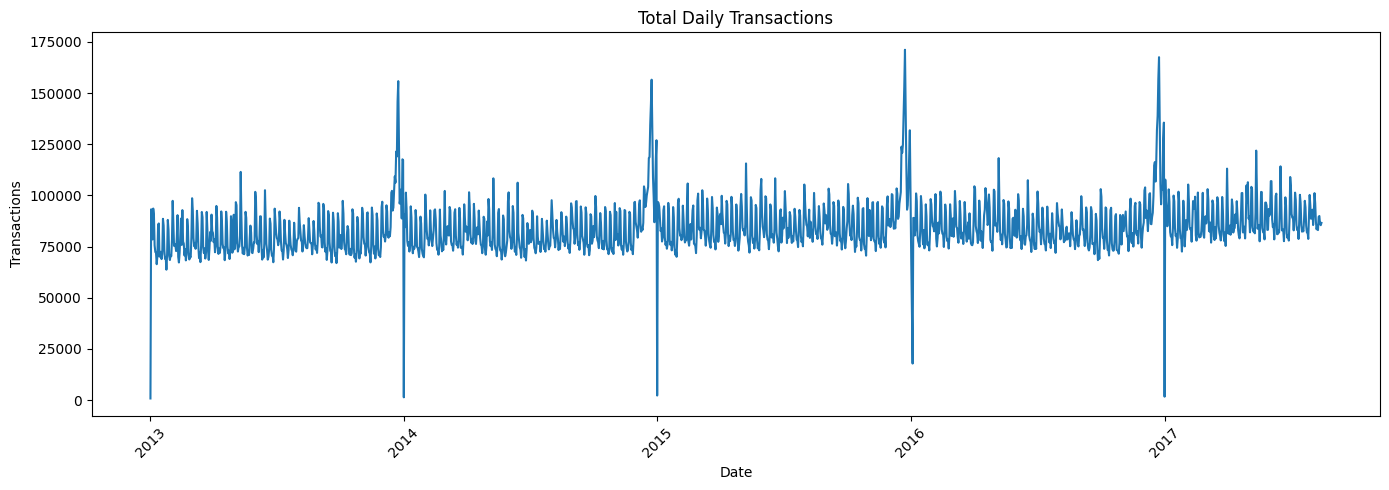

In [27]:
# Plot total daily transactions

plt.figure(figsize=(14, 5))
plt.plot(daily_transactions["date"], daily_transactions["total_transactions"])
plt.title("Total Daily Transactions")
plt.xlabel("Date")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
# Merge sales and transactions for relationship check

sales_transactions_df = daily_sales.merge(
    daily_transactions,
    on="date",
    how="inner"
)

sales_transactions_df[["total_sales", "total_transactions"]].corr()

,total_sales,total_transactions
total_sales,1.000000,0.676509
total_transactions,0.676509,1.000000


## Oil Price Analysis

This section reviews oil price behavior and checks whether it may be useful as a forecasting feature.

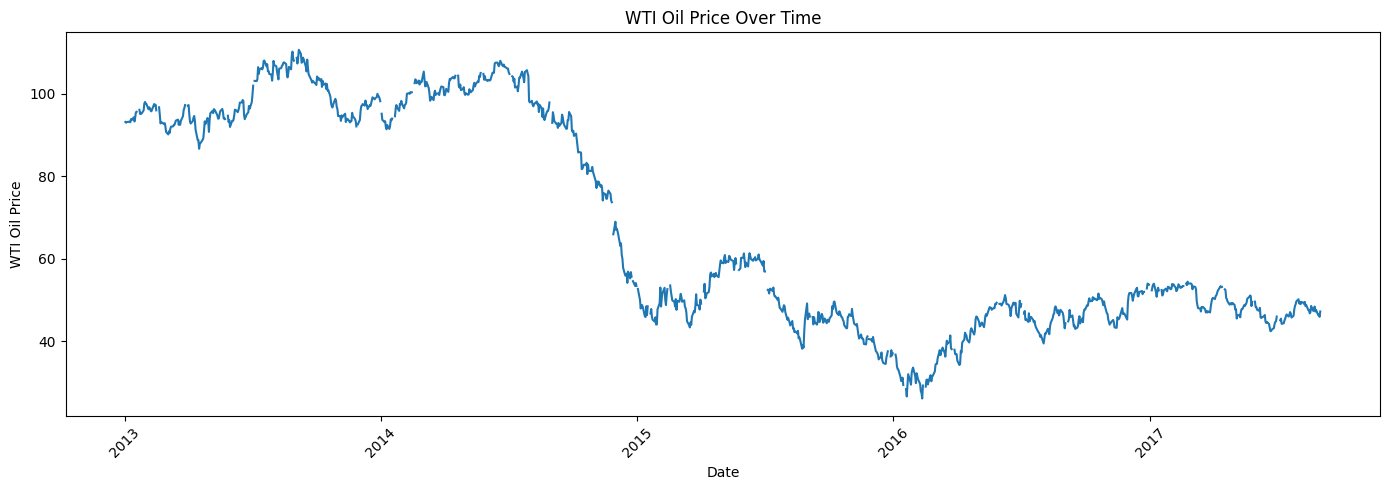

In [29]:
# Plot oil price series

plt.figure(figsize=(14, 5))
plt.plot(oil_df["date"], oil_df["dcoilwtico"])
plt.title("WTI Oil Price Over Time")
plt.xlabel("Date")
plt.ylabel("WTI Oil Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Merge oil and sales for relationship check

sales_oil_df = daily_sales.merge(
    oil_df[["date", "dcoilwtico"]],
    on="date",
    how="left"
)

sales_oil_df[["total_sales", "dcoilwtico"]].corr()

,total_sales,dcoilwtico
total_sales,1.000000,-0.705002
dcoilwtico,-0.705002,1.000000


## Save EDA Outputs

This section saves aggregated EDA tables that will be useful in feature engineering and later analysis.

In [31]:
# Save EDA output tables

daily_sales.to_csv(PREPROCESSED_DIR / "eda_daily_sales.csv", index=False)
ab_daily.to_csv(PREPROCESSED_DIR / "eda_ab_daily.csv", index=False)
daily_transactions.to_csv(PREPROCESSED_DIR / "eda_daily_transactions.csv", index=False)
sales_transactions_df.to_csv(PREPROCESSED_DIR / "eda_sales_transactions.csv", index=False)
sales_oil_df.to_csv(PREPROCESSED_DIR / "eda_sales_oil.csv", index=False)

print("EDA output tables saved successfully.")

EDA output tables saved successfully.
